In [ ]:
import pandas as pd
import requests

url = "https://api.thingspeak.com/channels/3250750/feeds.json?results=8000"
data = requests.get(url).json()

df = pd.DataFrame(data["feeds"])

df = df.rename(columns={
    "field1": "moisture",
    "field2": "temperature",
    "field3": "conductivity",
    "field4": "ph",
    "field5": "nitrogen",
    "field6": "phosphorus",
    "field7": "potassium"
})

cols = [
    "moisture", "temperature", "conductivity",
    "ph", "nitrogen", "phosphorus", "potassium"
]

df[cols] = df[cols].apply(pd.to_numeric, errors="coerce")
df["created_at"] = pd.to_datetime(df["created_at"])
df = df.sort_values("created_at").reset_index(drop=True)

print(len(df))


1084


In [ ]:
original_len = len(df)
df_clean = df[(df[cols] != 0).all(axis=1)]
print("Rows removed:", original_len - len(df_clean))
print("Percentage removed:", (original_len - len(df_clean)) / original_len * 100)


Rows removed: 19
Percentage removed: 1.7527675276752765


In [ ]:


print(f"Number of rows after removing zeros: {len(df)}")
print(df)

Number of rows after removing zeros: 1065
                    created_at  entry_id  moisture  temperature  conductivity  \
0    2026-02-04 15:36:55+00:00         1      55.6         18.8           646   
1    2026-02-04 15:37:12+00:00         2      55.4         18.8           645   
2    2026-02-04 15:37:29+00:00         3      55.6         18.8           645   
3    2026-02-04 15:37:46+00:00         4      55.6         18.8           644   
4    2026-02-04 15:38:02+00:00         5      55.4         18.8           642   
...                        ...       ...       ...          ...           ...   
1060 2026-02-05 11:43:15+00:00      1069     358.6        102.4         47361   
1061 2026-02-05 11:43:31+00:00      1070     358.6         51.2         47105   
1062 2026-02-05 11:43:48+00:00      1071     358.6         51.2         47105   
1063 2026-02-05 11:44:05+00:00      1072     358.6        102.4         47105   
1064 2026-02-05 11:44:21+00:00      1073     358.6        102.4    

In [ ]:
print(df.describe())


          entry_id     moisture  temperature  conductivity           ph  \
count  1065.000000  1065.000000   1065.00000    1065.00000  1065.000000   
mean    539.242254   331.472300   1055.59662   49316.73615  2961.708263   
std     309.213253    86.724722    695.44116   15635.71668  2073.106009   
min       1.000000    53.100000     18.50000     559.00000     5.900000   
25%     273.000000   358.600000    409.60000   49665.00000  1536.000000   
50%     539.000000   358.600000   1126.40000   54274.00000  1996.800000   
75%     807.000000   358.600000   1740.80000   56578.00000  5299.200000   
max    1073.000000   358.600000   2124.80000   59394.00000  6528.000000   

           nitrogen    phosphorus     potassium  moisture_avg  
count   1065.000000   1065.000000   1065.000000   1016.000000  
mean   16264.193427  16870.667606  49869.124883    337.480907  
std     5356.050093   5896.211755  16808.374168     72.299206  
min       78.000000    226.000000    220.000000     53.810000  
25% 

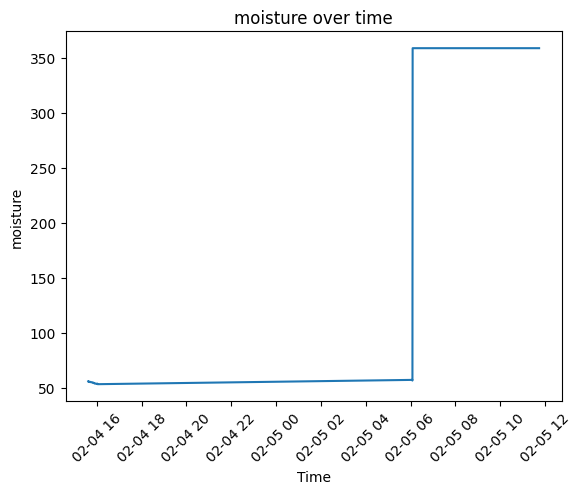

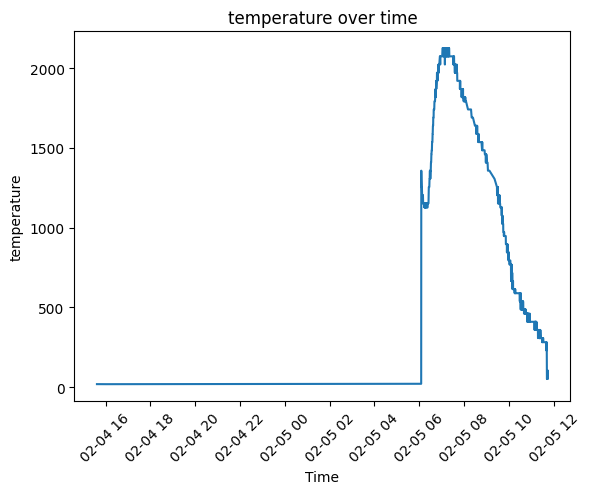

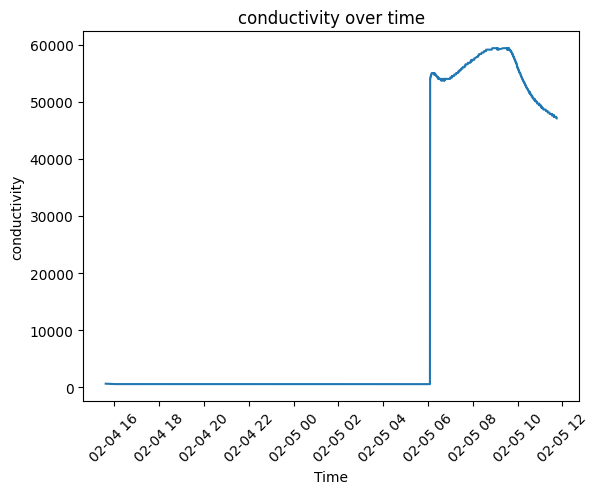

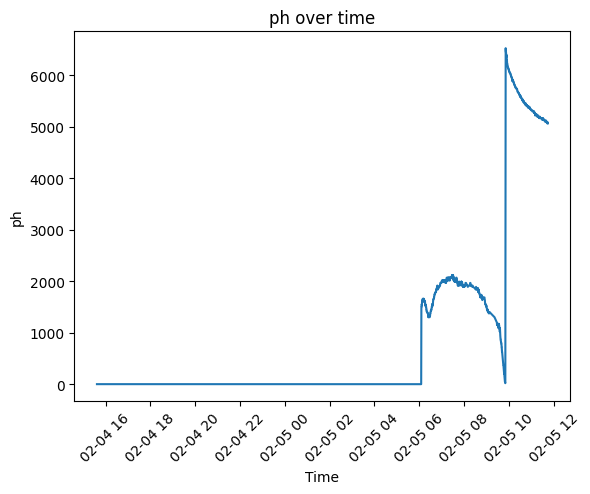

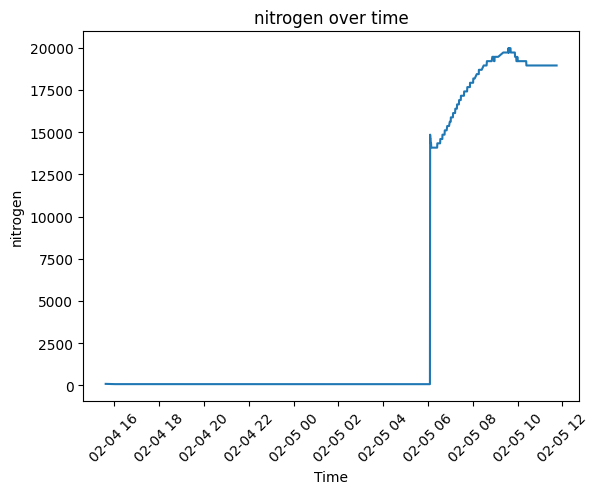

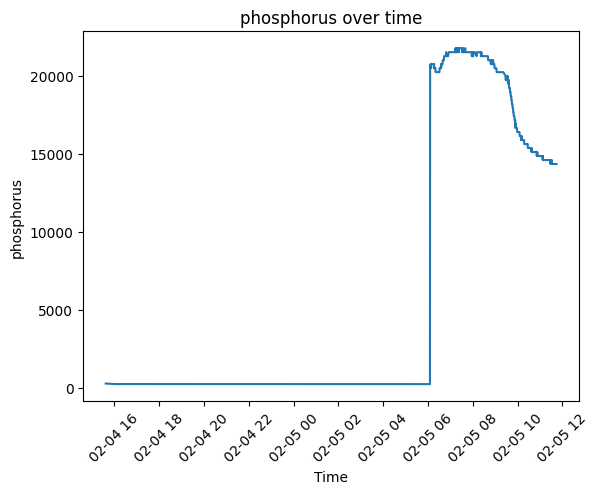

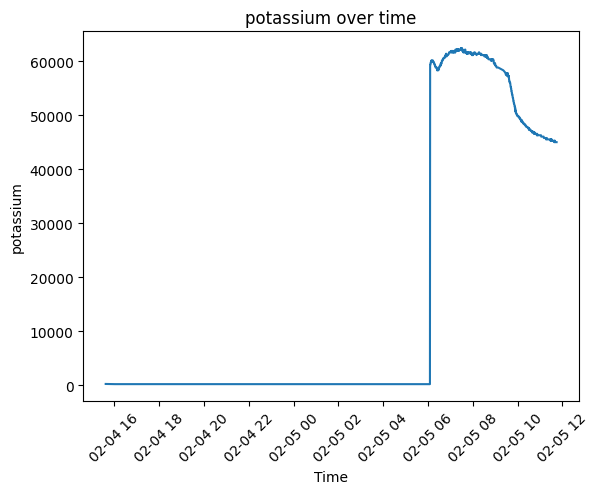

In [ ]:
import matplotlib.pyplot as plt

for col in cols:
    plt.figure()
    plt.plot(df["created_at"], df[col])
    plt.title(col + " over time")
    plt.xlabel("Time")
    plt.ylabel(col)
    plt.xticks(rotation=45)
    plt.show()


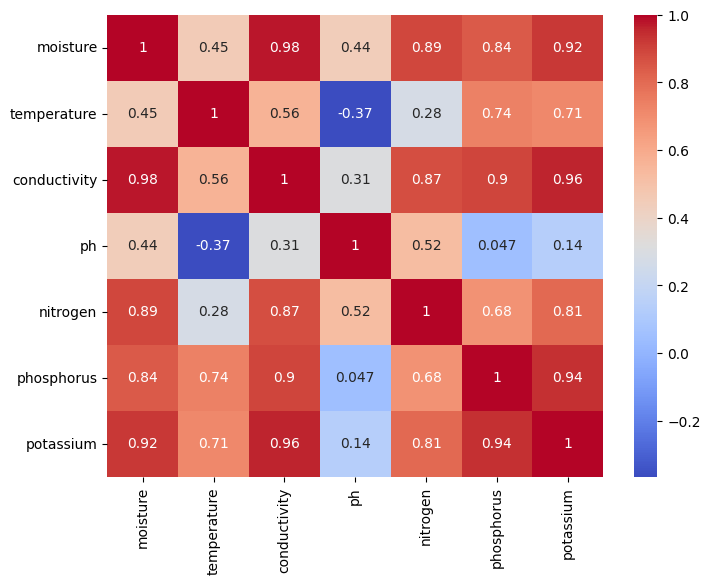

In [ ]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()


In [ ]:


low_moisture = df[df["moisture"] < 30]
high_temp = df[df["temperature"] > 35]
abnormal_ph = df[(df["ph"] < 5.5) | (df["ph"] > 7.5)]


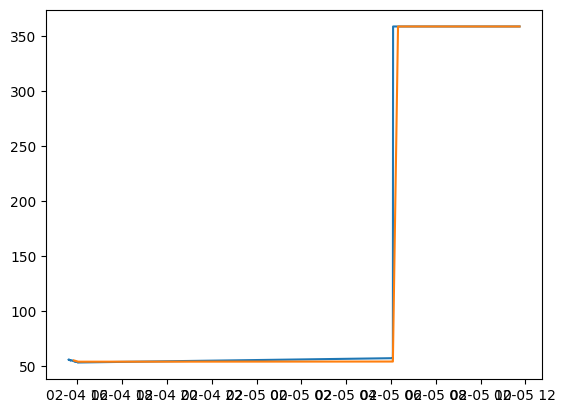

In [ ]:
df["moisture_avg"] = df["moisture"].rolling(window=50).mean()

plt.plot(df["created_at"], df["moisture"])
plt.plot(df["created_at"], df["moisture_avg"])
plt.show()


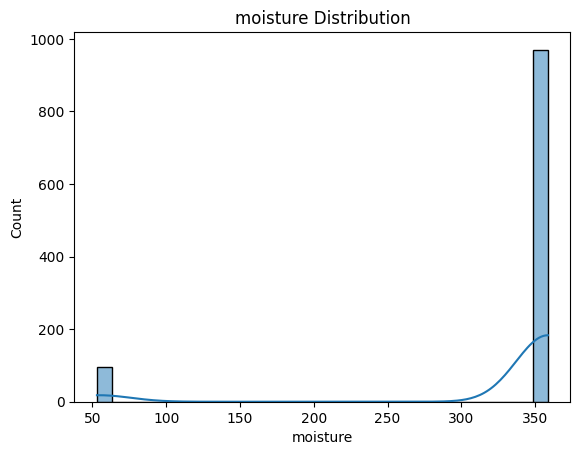

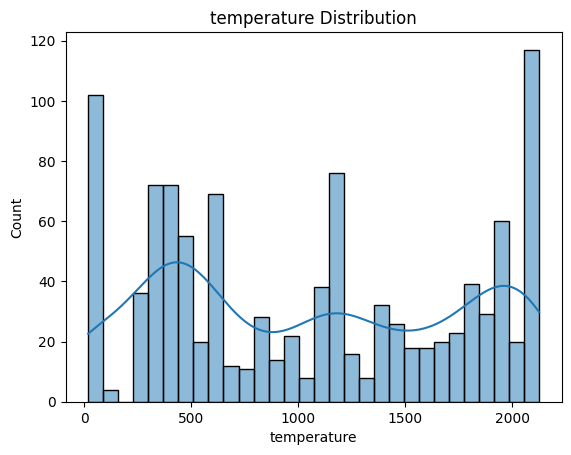

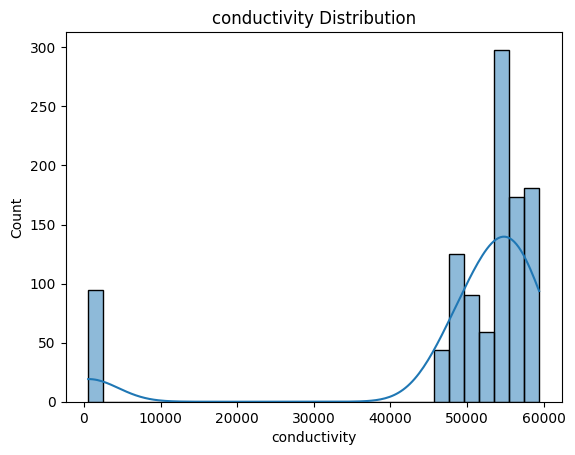

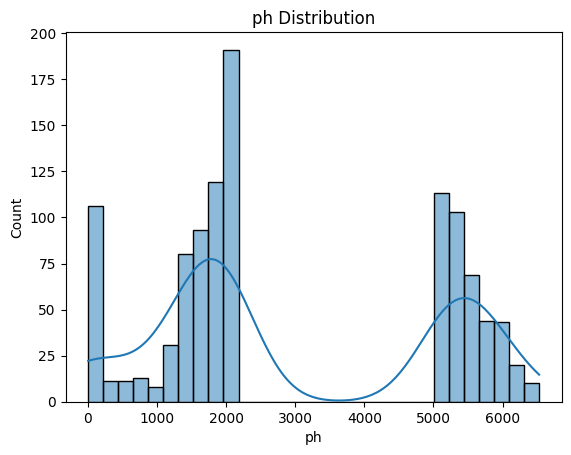

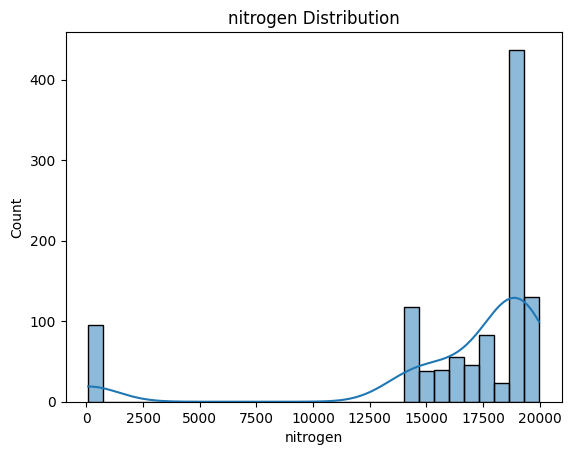

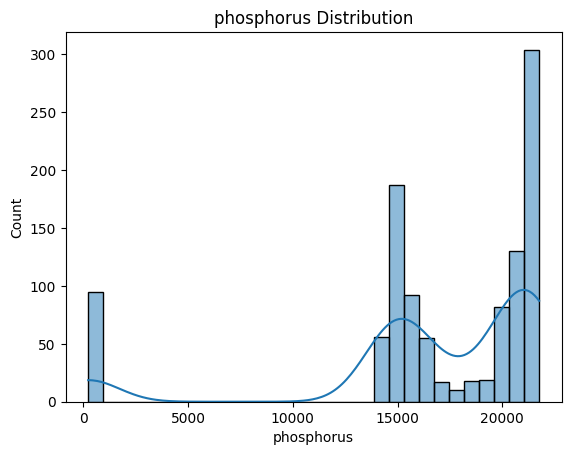

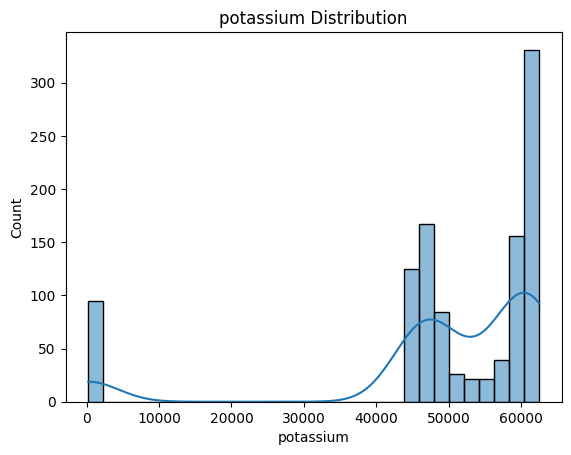

In [ ]:
for col in cols:
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(col + " Distribution")
    plt.show()


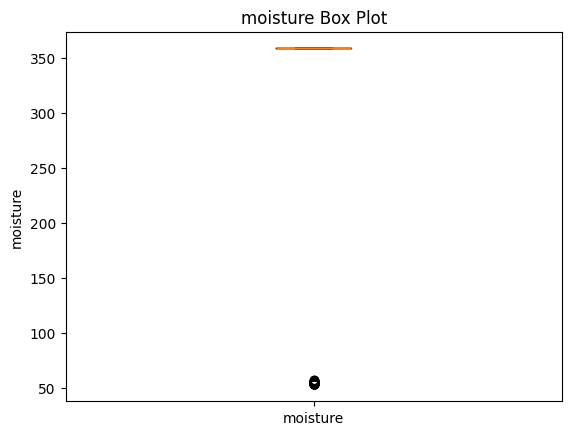

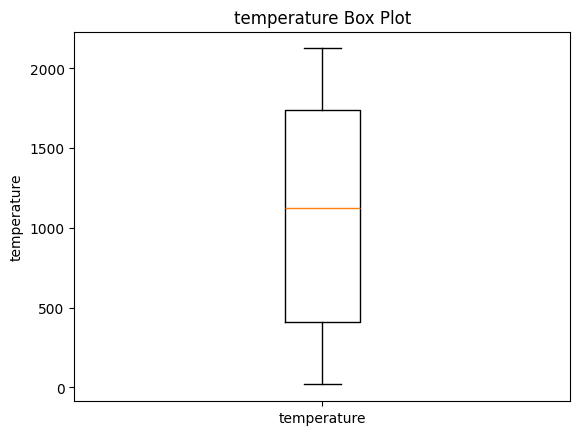

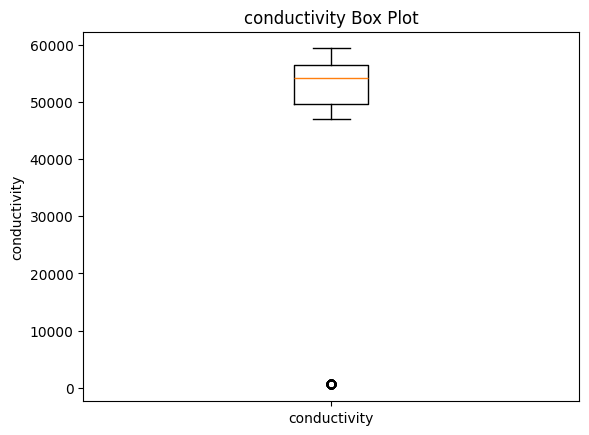

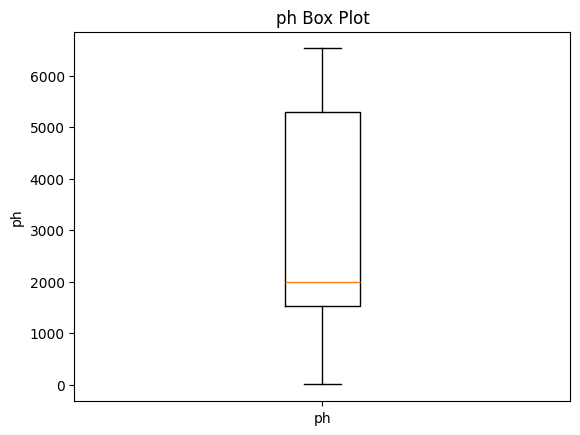

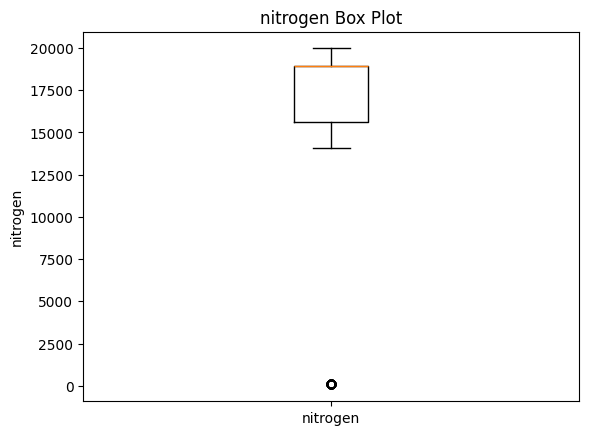

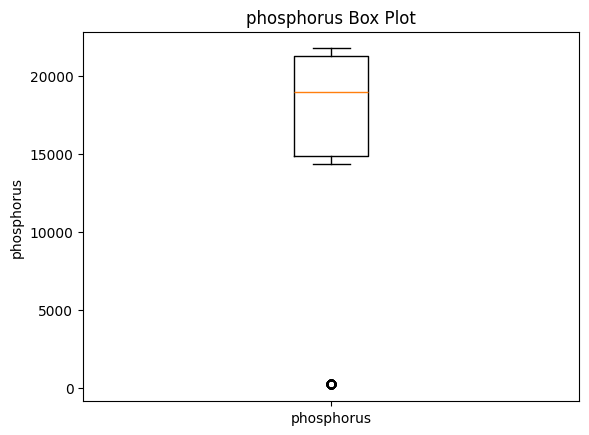

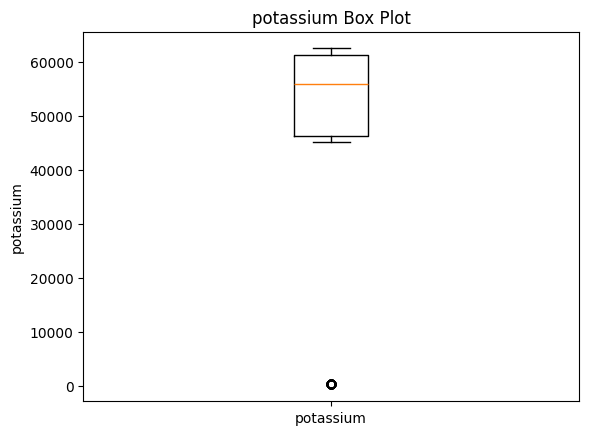

In [ ]:

cols = [
    "moisture", "temperature", "conductivity",
    "ph", "nitrogen", "phosphorus", "potassium"
]

for col in cols:
    plt.figure()
    plt.boxplot(df[col].dropna())
    plt.title(f"{col} Box Plot")
    plt.ylabel(col)
    plt.xticks([1], [col])
    plt.show()
